## RAVDESS DATASET

Ryerson Audio-Visual Database of Emotional Speech and Song (brief description)

## Imports

In [1]:
import pandas as pd
from scipy.io import wavfile
import seaborn as sns
import matplotlib.pyplot as plt
import parselmouth
import numpy as np
import os
import librosa
from IPython import display as ipd

In [2]:
# !pip install praat-parselmouth

In [ ]:
# !pip install librosa

In [ ]:
# !pip install resampy

## Reading the Data

In [2]:
# Create DataFrame with index `File_Name`
df = pd.read_csv('audio.csv')
df.set_index('File_Name', inplace=True)

In [3]:
# Show current DF
df.head()

,Actor,Gender,Emotion,Intensity,Statement,Repetition
File_Name,,,,,,
03-01-01-01-01-01-01.wav,1,M,neutral,normal,1,1
03-01-01-01-01-02-01.wav,1,M,neutral,normal,1,2
03-01-01-01-02-01-01.wav,1,M,neutral,normal,2,1
03-01-01-01-02-02-01.wav,1,M,neutral,normal,2,2
03-01-02-01-01-01-01.wav,1,M,calm,normal,1,1


In [4]:
df.describe()

,Actor,Statement,Repetition
count,1440.000000,1440.000000,1440.000000
mean,12.500000,1.500000,1.500000
std,6.924591,0.500174,0.500174
min,1.000000,1.000000,1.000000
25%,6.750000,1.000000,1.000000
50%,12.500000,1.500000,1.500000
75%,18.250000,2.000000,2.000000
max,24.000000,2.000000,2.000000


In [5]:
# Read WAV files
for f in df.index:
    rate, signal = wavfile.read('data/'+f)
    # Measure length of each audio file
    df.at[f, 'length'] = signal.shape[0]/rate

C:\Users\barry\AppData\Local\Temp\ipykernel_33360\4201303314.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, signal = wavfile.read('data/'+f)
C:\Users\barry\AppData\Local\Temp\ipykernel_33360\4201303314.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, signal = wavfile.read('data/'+f)


In [6]:
# Print all unique emotions in the dataset
print(df['Emotion'].unique())
class_distribution = df['Emotion'].value_counts()
print(class_distribution)

['neutral' 'calm' 'happy' 'sad' 'angry' 'fearful' 'disgust' 'surprised']
Emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64


In [14]:
# Oversampling
max_count = class_distribution.max()

# Create a new balanced DataFrame
balanced_df = pd.DataFrame()

for label in class_distribution.index:
    label_df = df[df['Emotion'] == label]
    
    # Oversample if the current class has less than max_count
    if len(label_df) < max_count:
        # Sample with replacement
        label_df = label_df.sample(max_count, replace=True)
    
    balanced_df = pd.concat([balanced_df, label_df], ignore_index=False)

# Check the new class distribution
print(balanced_df['Emotion'].value_counts())

Emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral      192
Name: count, dtype: int64


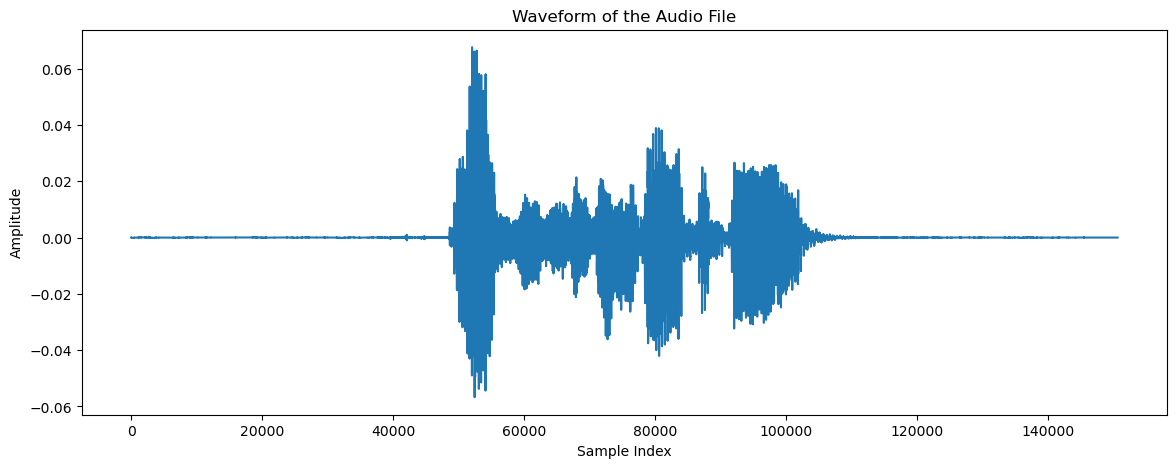

In [7]:
# Sample waveplot

# Load the audio file
file_path = 'data/03-01-03-01-02-01-13.wav'
sound = parselmouth.Sound(file_path)
audio_array = sound.values.T.flatten()

# Plot the waveform
plt.figure(figsize=(14, 5))
plt.plot(audio_array)
plt.title('Waveform of the Audio File')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

ipd.Audio(file_path)

## EDA

### Distribution of emotions in the dataset

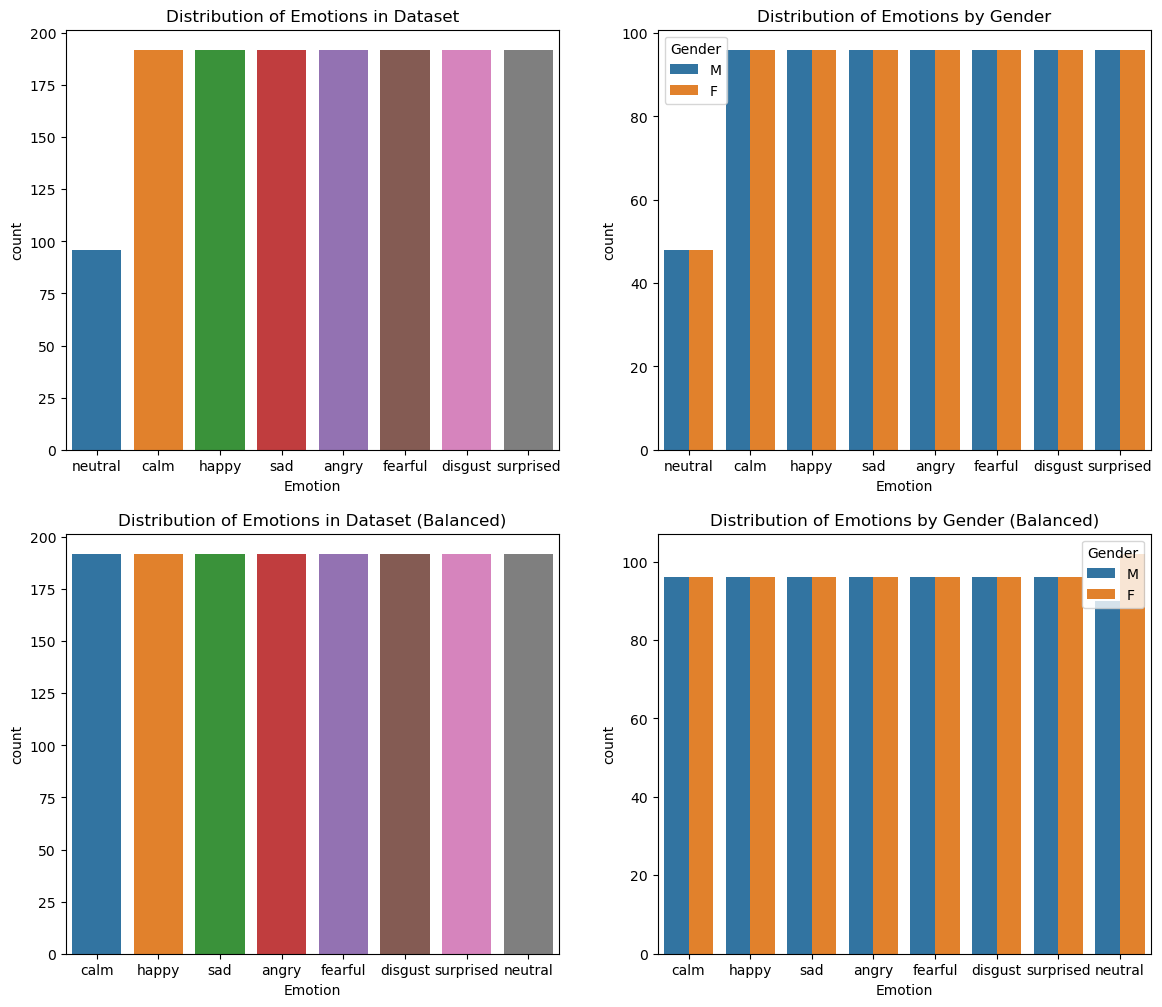

In [15]:
# Distribution of emotions in the dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
sns.countplot(x='Emotion', data=df, ax=axes[0,0])
axes[0,0].set_title("Distribution of Emotions in Dataset")

# Distribution of emotions in the dataset by Gender
sns.countplot(x='Emotion', hue='Gender', data=df, ax=axes[0,1])
axes[0,1].set_title("Distribution of Emotions by Gender")

# Distribution of emotions in the dataset (Balanced)
sns.countplot(x='Emotion', data=balanced_df, ax=axes[1,0])
axes[1,0].set_title("Distribution of Emotions in Dataset (Balanced)")

# Distribution of emotions in the dataset by Gender (Balanced)
sns.countplot(x='Emotion', hue='Gender', data=balanced_df, ax=axes[1,1])
axes[1,1].set_title("Distribution of Emotions by Gender (Balanced)")

plt.show()

### Duration of audio files

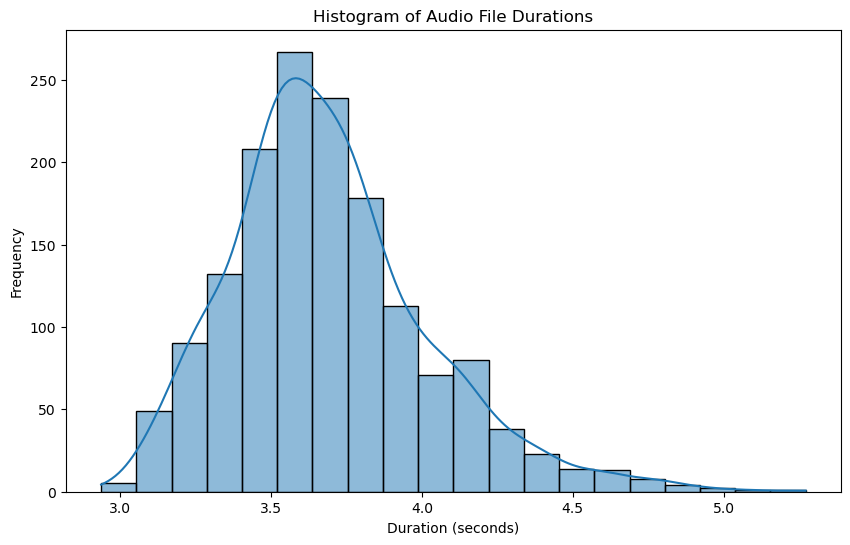

In [16]:
# What is the duration of the audio files?
plt.figure(figsize=(10, 6))
sns.histplot(balanced_df['length'], bins=20, kde=True)
plt.title('Histogram of Audio File Durations')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

### Features

#### Mean Pitch

In [10]:
# Directory containing your audio files
audio_dir = "data/"

# List to store pitch data for each file
pitch_data = []

# List of audio files
audio_files = [f for f in os.listdir(audio_dir) if f.endswith(".wav")]

# Loop over each audio file
for file in audio_files:
    # Load the sound file
    snd = parselmouth.Sound(os.path.join(audio_dir, file))
    
    # Extract pitch
    pitch = snd.to_pitch()
    pitch_values = pitch.selected_array['frequency']
    
    # Use a summary statistic (e.g., mean, median) if pitch length differs across files
    pitch_mean = np.mean(pitch_values)
    
    balanced_df.at[file, 'Mean Pitch'] = pitch_mean
    
    # Append the pitch mean to pitch_data list
    # pitch_data.append(pitch_mean)


#### Mean Intensity

In [11]:
# Directory containing your audio files
audio_dir = "data/"

# List to store intensity data for each file
intensity_data = []

# List of audio files
audio_files = [f for f in os.listdir(audio_dir) if f.endswith(".wav")]

# Loop over each audio file
for file in audio_files:
    # Load the sound file
    snd = parselmouth.Sound(os.path.join(audio_dir, file))
    
    # Extract intensity
    intensity = snd.to_intensity()
    intensity_values = intensity.values.T.flatten()  # Flatten to a 1D array
    
    # Use a summary statistic (e.g., mean) if intensity length differs across files
    intensity_mean = np.mean(intensity_values)
    
    df.at[file, 'Mean Intensity'] = intensity_mean
    
    # Append the intensity mean to intensity_data list
    #intensity_data.append(intensity_mean)

# Create a DataFrame with file names as index and intensity means as a column
#df = pd.DataFrame(intensity_data, index=audio_files, columns=["Mean Intensity"])

# Display the DataFrame
#print(df)


In [12]:
# Check modified/updated df
df.head()

,Actor,Gender,Emotion,Intensity,Statement,Repetition,length,Mean Pitch,Mean Intensity
File_Name,,,,,,,,,
03-01-01-01-01-01-01.wav,1,M,neutral,normal,1,1,3.303292,34.546637,13.611322
03-01-01-01-01-02-01.wav,1,M,neutral,normal,1,2,3.336667,37.660537,15.508136
03-01-01-01-02-01-01.wav,1,M,neutral,normal,2,1,3.269917,36.515771,14.725629
03-01-01-01-02-02-01.wav,1,M,neutral,normal,2,2,3.169833,34.807093,16.049077
03-01-02-01-01-01-01.wav,1,M,calm,normal,1,1,3.536854,39.075821,12.647445


#### Mel-Frequency Cepstral Coefficients (MFCC)

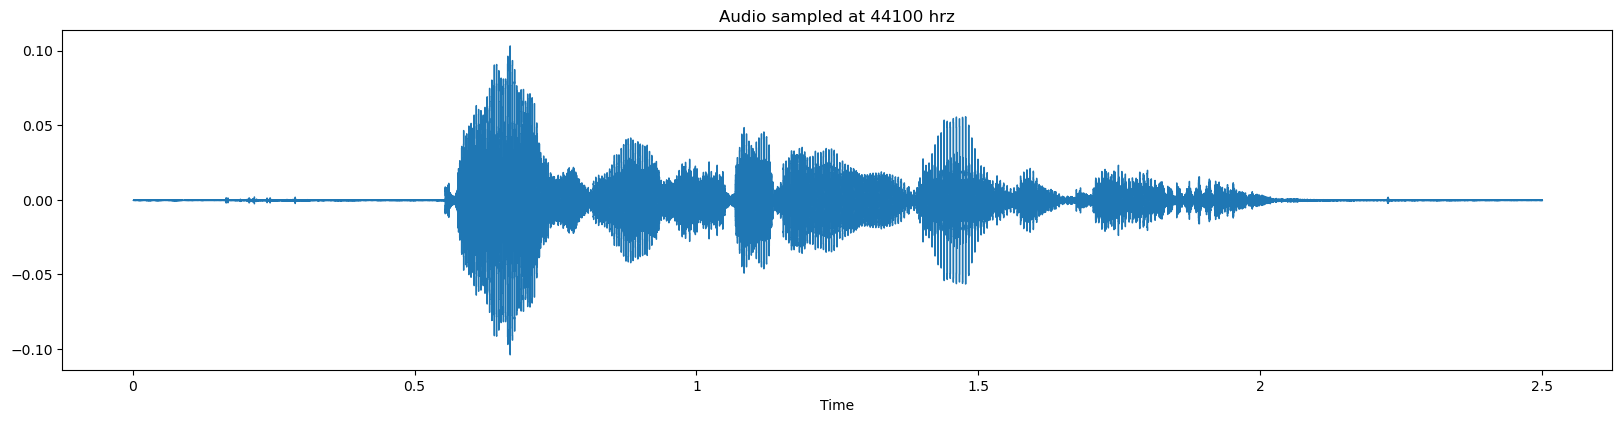

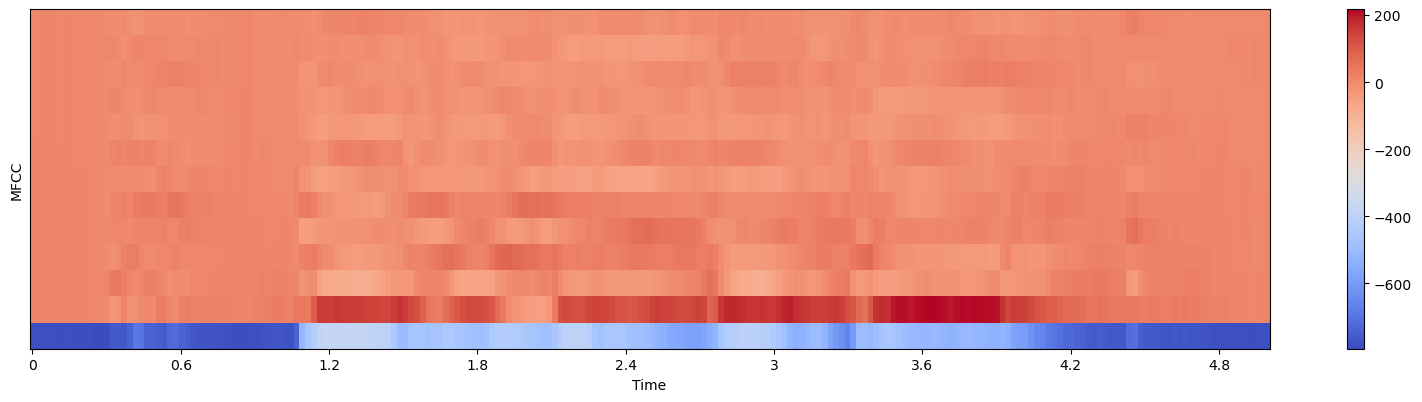

In [17]:
# Gender - Female; Emotion - Happy 
file = 'data/03-01-03-01-02-02-08.wav'
X, sample_rate = librosa.load(file, res_type='kaiser_fast',duration=2.5,sr=22050*2,offset=0.5)  
female_happy_mfcc = librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=13)

# audio wave
plt.figure(figsize=(20, 15))
plt.subplot(3,1,1)
librosa.display.waveshow(X, sr=sample_rate)
plt.title('Audio sampled at 44100 hrz')

# MFCC
plt.figure(figsize=(20, 15))
plt.subplot(3,1,1)
librosa.display.specshow(female_happy_mfcc, x_axis='time')
plt.ylabel('MFCC')
plt.colorbar()

ipd.Audio(file)

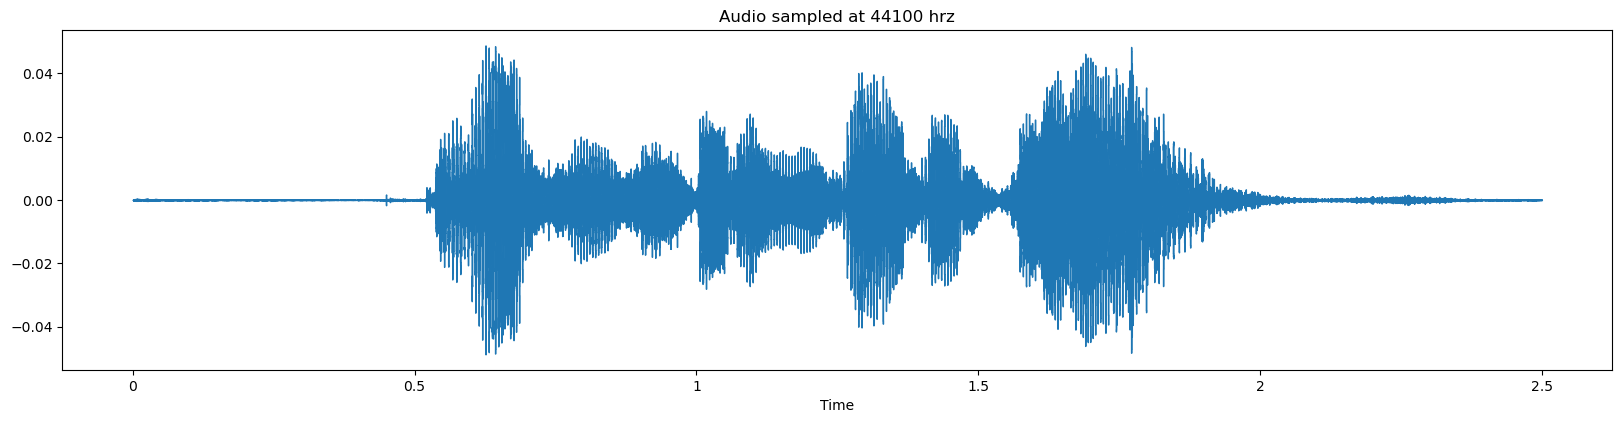

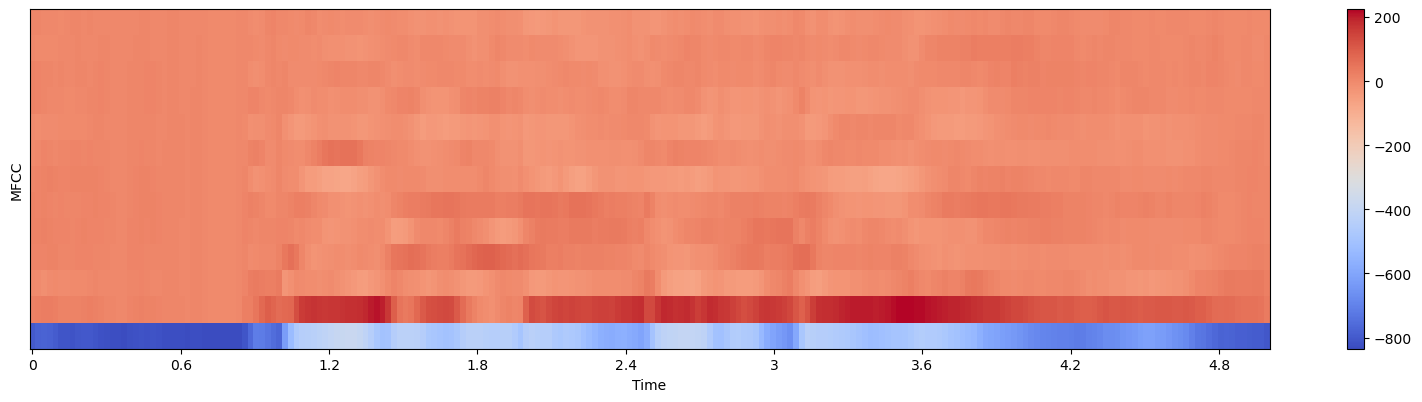

In [15]:
# Gender - Male; Emotion - Happy 
file = 'data/03-01-03-01-02-02-07.wav'
X, sample_rate = librosa.load(file, res_type='kaiser_fast',duration=2.5,sr=22050*2,offset=0.5)  
male_happy_mfcc = librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=13)

# audio wave
plt.figure(figsize=(20, 15))
plt.subplot(3,1,1)
librosa.display.waveshow(X, sr=sample_rate)
plt.title('Audio sampled at 44100 hrz')

# MFCC
plt.figure(figsize=(20, 15))
plt.subplot(3,1,1)
librosa.display.specshow(male_happy_mfcc, x_axis='time')
plt.ylabel('MFCC')
plt.colorbar()

ipd.Audio(file)

### How do features vary accross different emotion

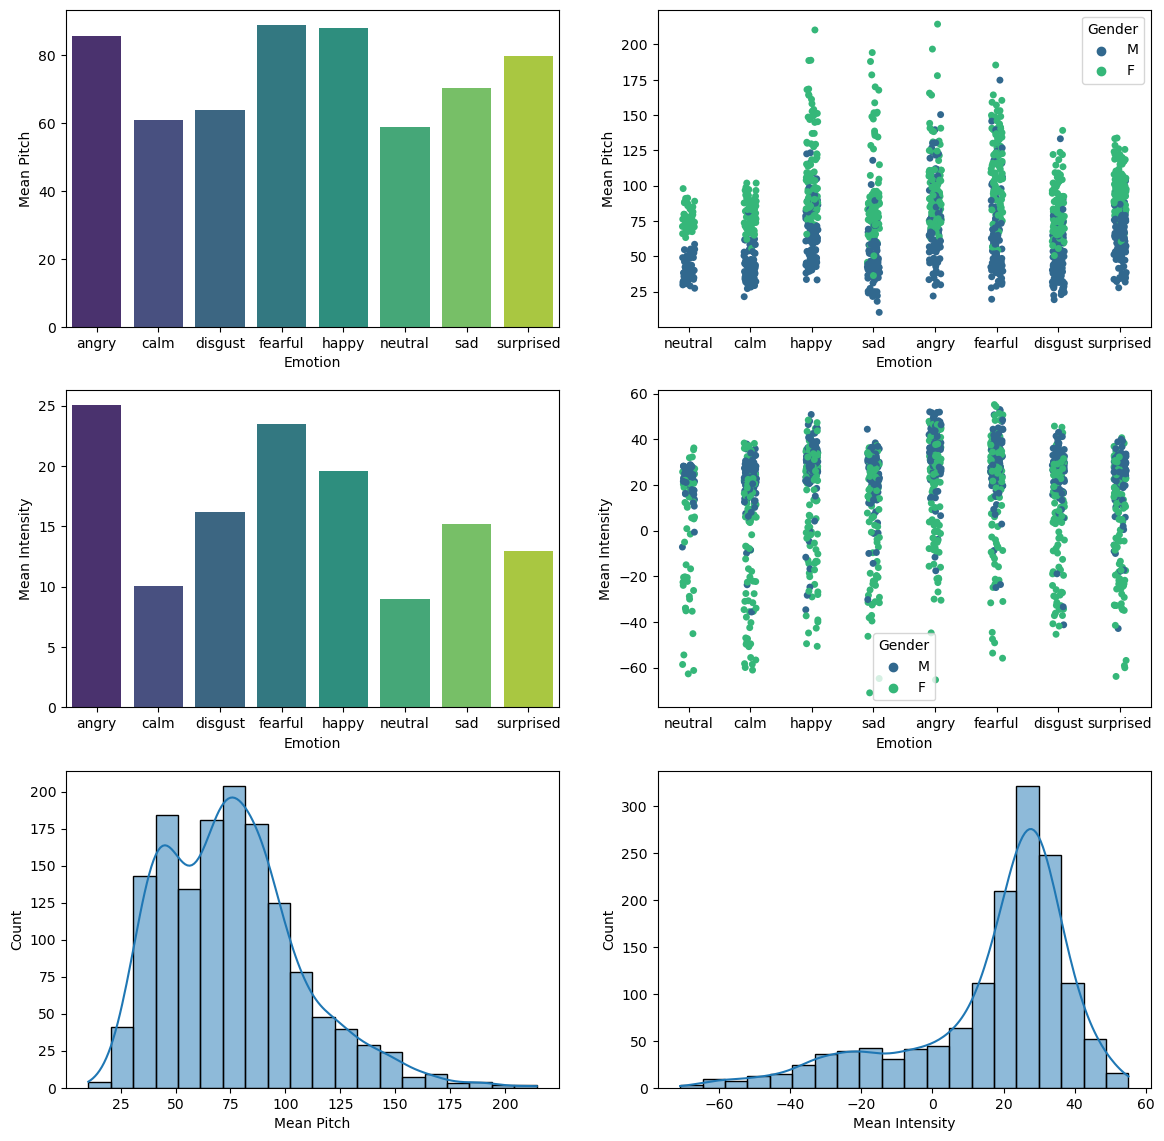

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [31]:
# Calculate mean or median for Pitch and Intensity
pitch_means = df.groupby('Emotion')['Mean Pitch'].mean().reset_index()
intensity_means = df.groupby('Emotion')['Mean Intensity'].mean().reset_index()

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Plot for Pitch
plt.figure(figsize=(10, 6))
sns.barplot(x='Emotion', y='Mean Pitch', data=pitch_means, palette='viridis', ax=axes[0, 0])
sns.stripplot(data=df, x="Emotion", y="Mean Pitch", hue='Gender', palette='viridis', jitter=True, ax=axes[0, 1])
# plt.title('Pitch by Emotion')
# plt.xlabel('Emotion')
# plt.ylabel('Pitch')
# plt.show()

# Plot for Intensity
plt.figure(figsize=(10, 6))
sns.barplot(x='Emotion', y='Mean Intensity', data=intensity_means, palette='viridis', ax=axes[1, 0])
sns.stripplot(data=df, x="Emotion", y="Mean Intensity", hue='Gender', palette='viridis', jitter=True, ax=axes[1, 1])
# plt.title('Intensity by Emotion')
# plt.xlabel('Emotion')
# plt.ylabel('Intensity')

sns.histplot(df['Mean Pitch'], bins=20, kde=True, ax=axes[2, 0])
sns.histplot(df['Mean Intensity'], bins=20, kde=True, ax=axes[2, 1])
plt.show()

In [20]:
# Printing values
sorted_pitch_means = pitch_means.sort_values(by='Mean Pitch', ascending=False)
sorted_intensity_means = intensity_means.sort_values(by='Mean Intensity', ascending=False)

print("Average Pitch by Emotion:")
print(sorted_pitch_means)

print("\nAverage Intensity by Emotion:")
print(sorted_intensity_means)

Average Pitch by Emotion:
     Emotion  Mean Pitch
3    fearful   88.948250
4      happy   87.920750
0      angry   85.705901
7  surprised   79.713561
6        sad   70.245641
2    disgust   63.947939
1       calm   60.963129
5    neutral   58.904898

Average Intensity by Emotion:
     Emotion  Mean Intensity
0      angry       25.018208
3    fearful       23.456459
4      happy       19.600386
2    disgust       16.154021
6        sad       15.191765
7  surprised       12.951000
1       calm       10.037127
5    neutral        8.933323


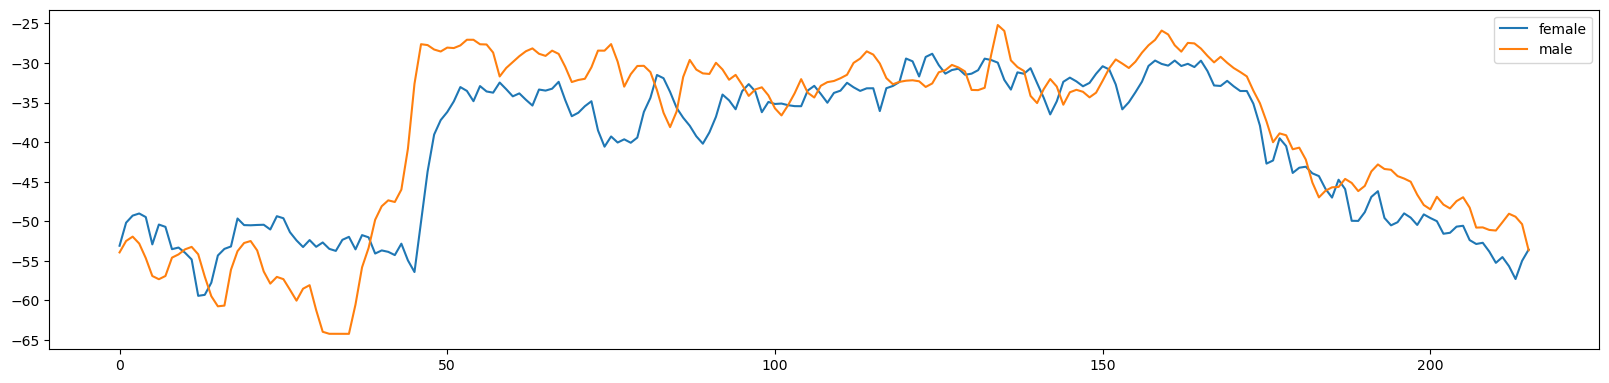

In [40]:
# MFCCs average among different emotion and gender
female_happy_mfcc_mean = np.mean(female_happy_mfcc, axis=0)
male_happy_mfcc_mean = np.mean(male_happy_mfcc, axis=0)

# print(len(female_happy_mfcc_mean))
# print(len(male_happy_mfcc_mean))

# audio wave
plt.figure(figsize=(20, 15))
plt.subplot(3,1,1)
plt.plot(female_happy_mfcc_mean, label='female')
plt.plot(male_happy_mfcc_mean, label='male')
plt.legend()
plt.show()

### Correlations

In [21]:
# Calculations
from scipy.stats import pearsonr, spearmanr, kendalltau

# Pearson correlation
pearson_corr, _ = pearsonr(df['Mean Pitch'], df['Mean Intensity'])
print("Pearson correlation:", pearson_corr)

# Spearman correlation
spearman_corr, _ = spearmanr(df['Mean Pitch'], df['Mean Intensity'])
print("Spearman correlation:", spearman_corr)

# Kendall correlation
kendall_corr, _ = kendalltau(df['Mean Pitch'], df['Mean Intensity'])
print("Kendall correlation:", kendall_corr)

Pearson correlation: 0.008832705260363937
Spearman correlation: 0.0783363391345521
Kendall correlation: 0.05888643626596042


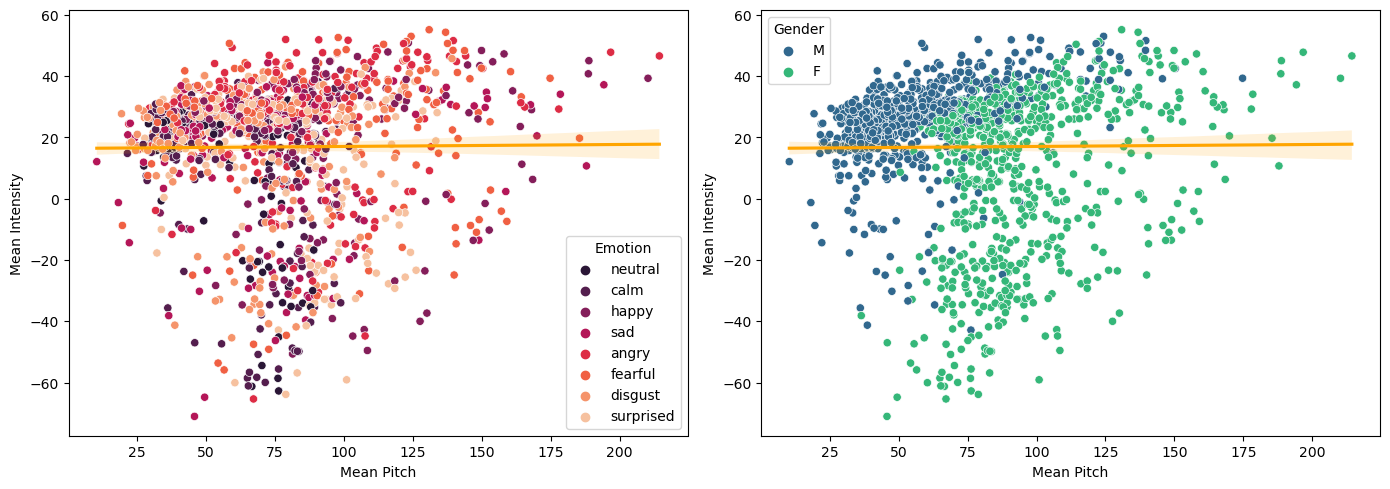

In [19]:
# Scatter plot with regression line

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='Mean Pitch', y='Mean Intensity', hue='Emotion', data=df, palette='rocket', ax=axes[0])
sns.scatterplot(x='Mean Pitch', y='Mean Intensity', hue='Gender', data=df, palette='viridis', ax=axes[1])
sns.regplot(x='Mean Pitch', y='Mean Intensity', data=df, scatter=False, color='orange', ax=axes[0])
sns.regplot(x='Mean Pitch', y='Mean Intensity', data=df, scatter=False, color='orange', ax=axes[1])
# plt.title('Scatter Plot of Pitch vs. Intensity')
# plt.xlabel('Mean Pitch')
# plt.ylabel('Mean Intensity')
# plt.grid(True)
plt.tight_layout()
plt.show()

## Model Preparation

## Extra